In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(r"D:\Python project\PROJECT")
TARGET = "Attack Type"

In [2]:
train_df = pd.read_csv(
    PROJECT_ROOT / "data" / "splits" / "train.csv",
    low_memory=False
)

val_df = pd.read_csv(
    PROJECT_ROOT / "data" / "splits" / "validation.csv",
    low_memory=False
)

test_df = pd.read_csv(
    PROJECT_ROOT / "data" / "splits" / "test.csv",
    low_memory=False
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1764413, 53)
Validation: (378088, 53)
Test: (378089, 53)


In [3]:
feature_cols = [
    col for col in train_df.columns
    if col != TARGET
]

print("Number of features:", len(feature_cols))
print("Target classes:")
print(train_df[TARGET].value_counts())

print(
    "Non-numeric features:",
    train_df[feature_cols]
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

Number of features: 52
Target classes:
Attack Type
Normal Traffic    1466427
DoS                135621
DDoS                89610
Port Scanning       63486
Brute Force          6405
Web Attacks          1500
Bots                 1364
Name: count, dtype: int64
Non-numeric features: []


In [4]:
X_train = train_df[feature_cols] 
y_train = train_df[TARGET] 

X_test = test_df[feature_cols] 
y_test = test_df[TARGET] 

X_val = val_df[feature_cols] 
y_val = val_df[TARGET]


In [5]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (1764413, 52)
y_train: (1764413,)


In [6]:
from sklearn.preprocessing import LabelEncoder 

label_encoder = LabelEncoder() 

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test) 
y_val_encoded = label_encoder.transform(y_val)

for number, label in enumerate(label_encoder.classes_) :
    print(number, "->", label)

0 -> Bots
1 -> Brute Force
2 -> DDoS
3 -> DoS
4 -> Normal Traffic
5 -> Port Scanning
6 -> Web Attacks


In [7]:
print("Number of classes:", len(label_encoder.classes_))
print("Encoded labels:", sorted(set(y_train_encoded)))

Number of classes: 7
Encoded labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [8]:
from xgboost import XGBClassifier

num_classes = len(label_encoder.classes_)

xgb_model = XGBClassifier(
    objective="multi:softprob", # phan loai nhieu lop => softmax pro 
    num_class=num_classes,

    n_estimators=100, # so cay
    max_depth=6,
    learning_rate=0.1,

    subsample=0.8,  # lay 1 phan du lieu => giam overfittin 
    colsample_bytree=0.8,

    tree_method="hist",    # train du lieu lon nhanh hon 
    eval_metric="mlogloss",

    early_stopping_rounds=10, # dung som khi khong cai thien 
    random_state=42,
    n_jobs=-1
)

In [9]:
xgb_model.fit(
    X_train,
    y_train_encoded,
    eval_set=[
        (X_val, y_val_encoded)
    ],
    verbose=10
)

[0]	validation_0-mlogloss:0.45144
[10]	validation_0-mlogloss:0.12710
[20]	validation_0-mlogloss:0.04983
[30]	validation_0-mlogloss:0.02227
[40]	validation_0-mlogloss:0.01184
[50]	validation_0-mlogloss:0.00757
[60]	validation_0-mlogloss:0.00557
[70]	validation_0-mlogloss:0.00461
[80]	validation_0-mlogloss:0.00407
[90]	validation_0-mlogloss:0.00373
[99]	validation_0-mlogloss:0.00353


,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegr

In [ ]:
print("Best iteration:", xgb_model.best_iteration) # lop 99 lan => van tot do cchua dung som 
print("Best score:", xgb_model.best_score) # chua du de ket luan 

Best iteration: 99
Best score: 0.00353117836263065


In [11]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

In [12]:
y_val_pred = xgb_model.predict(X_val).astype(int).ravel()

print("Accuracy:", accuracy_score(y_val_encoded, y_val_pred))
print(
    "Macro F1:",
    f1_score(y_val_encoded, y_val_pred, average="macro")
)
print(
    "Weighted F1:",
    f1_score(y_val_encoded, y_val_pred, average="weighted")
)

Accuracy: 0.9990689998095681
Macro F1: 0.9655568646316895
Weighted F1: 0.9990467260772115


In [13]:
print(
    classification_report(
        y_val_encoded,
        y_val_pred,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

                precision    recall  f1-score   support

          Bots     0.9159    0.6712    0.7747       292
   Brute Force     1.0000    0.9993    0.9996      1372
          DDoS     0.9998    0.9995    0.9997     19202
           DoS     0.9979    0.9994    0.9987     29062
Normal Traffic     0.9996    0.9993    0.9995    314234
 Port Scanning     0.9896    0.9996    0.9946     13604
   Web Attacks     0.9969    0.9876    0.9922       322

      accuracy                         0.9991    378088
     macro avg     0.9857    0.9508    0.9656    378088
  weighted avg     0.9991    0.9991    0.9990    378088



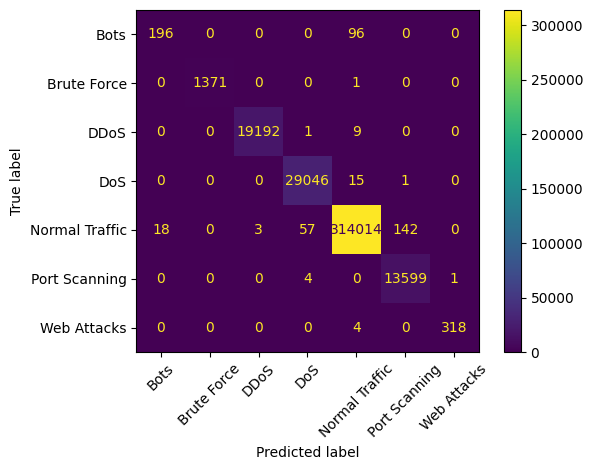

In [14]:
cm = confusion_matrix(
    y_val_encoded,
    y_val_pred,
    labels=np.arange(num_classes)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

In [15]:
report = classification_report(
    y_val_encoded,
    y_val_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    digits=4,
    zero_division=0
)

report_df = pd.DataFrame(report).T
display(report_df)

,precision,recall,f1-score,support
Bots,0.915888,0.671233,0.774704,292.000000
Brute Force,1.000000,0.999271,0.999635,1372.000000
DDoS,0.999844,0.999479,0.999661,19202.000000
DoS,0.997870,0.999449,0.998659,29062.000000
Normal Traffic,0.999602,0.999300,0.999451,314234.000000
Port Scanning,0.989594,0.999632,0.994588,13604.000000
Web Attacks,0.996865,0.987578,0.992200,322.000000
accuracy,0.999069,0.999069,0.999069,0.999069
macro avg,0.985666,0.950849,0.965557,378088.000000
weighted avg,0.999056,0.999069,0.999047,378088.000000


In [16]:
cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

display(cm_df)

,Bots,Brute Force,DDoS,DoS,Normal Traffic,Port Scanning,Web Attacks
Bots,196,0,0,0,96,0,0
Brute Force,0,1371,0,0,1,0,0
DDoS,0,0,19192,1,9,0,0
DoS,0,0,0,29046,15,1,0
Normal Traffic,18,0,3,57,314014,142,0
Port Scanning,0,0,0,4,0,13599,1
Web Attacks,0,0,0,0,4,0,318


In [17]:
bots_index = list(label_encoder.classes_).index("Bots")

bots_mask = y_val_encoded == bots_index

bots_predictions = label_encoder.inverse_transform(
    y_val_pred[bots_mask]
)

bots_errors = (
    pd.Series(bots_predictions)
    .value_counts()
    .rename_axis("Predicted as")
    .to_frame("Count")
)

display(bots_errors)

,Count
Predicted as,
Bots,196
Normal Traffic,96


In [18]:
bots_index = list(label_encoder.classes_).index("Bots")

train_weights = np.ones(
    len(y_train_encoded),
    dtype=np.float32
)

train_weights[y_train_encoded == bots_index] = 3.0

print("Bots index:", bots_index)
print("Bots weight:", train_weights[y_train_encoded == bots_index][0])

Bots index: 0
Bots weight: 3.0


In [19]:
xgb_weighted = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,

    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=10,

    random_state=42,
    n_jobs=-1
)

In [20]:
xgb_weighted.fit(
    X_train,
    y_train_encoded,
    sample_weight=train_weights,
    eval_set=[
        (X_val, y_val_encoded)
    ],
    verbose=10
)

[0]	validation_0-mlogloss:0.44942
[10]	validation_0-mlogloss:0.13085
[20]	validation_0-mlogloss:0.05100
[30]	validation_0-mlogloss:0.02303
[40]	validation_0-mlogloss:0.01226
[50]	validation_0-mlogloss:0.00789
[60]	validation_0-mlogloss:0.00583
[70]	validation_0-mlogloss:0.00483
[80]	validation_0-mlogloss:0.00429
[90]	validation_0-mlogloss:0.00393
[99]	validation_0-mlogloss:0.00372


,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegr

In [21]:
y_val_pred_weighted = (
    xgb_weighted
    .predict(X_val)
    .astype(int)
    .ravel()
)

print(
    classification_report(
        y_val_encoded,
        y_val_pred_weighted,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

                precision    recall  f1-score   support

          Bots     0.7113    0.9281    0.8053       292
   Brute Force     1.0000    0.9993    0.9996      1372
          DDoS     0.9998    0.9995    0.9997     19202
           DoS     0.9978    0.9994    0.9986     29062
Normal Traffic     0.9998    0.9990    0.9994    314234
 Port Scanning     0.9896    0.9996    0.9946     13604
   Web Attacks     0.9969    0.9876    0.9922       322

      accuracy                         0.9990    378088
     macro avg     0.9565    0.9875    0.9699    378088
  weighted avg     0.9991    0.9990    0.9990    378088



In [23]:
import sys

print(sys.executable)

d:\Python project\.venv\Scripts\python.exe


In [22]:
import torch
import xgboost

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("XGBoost CUDA:", xgboost.build_info()["USE_CUDA"])

CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
XGBoost CUDA: True


In [24]:
print(
    classification_report(
        y_val_encoded,
        y_val_pred_weighted,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

print(
    "Weighted Macro F1:",
    f1_score(
        y_val_encoded,
        y_val_pred_weighted,
        average="macro"
    )
)

                precision    recall  f1-score   support

          Bots     0.7113    0.9281    0.8053       292
   Brute Force     1.0000    0.9993    0.9996      1372
          DDoS     0.9998    0.9995    0.9997     19202
           DoS     0.9978    0.9994    0.9986     29062
Normal Traffic     0.9998    0.9990    0.9994    314234
 Port Scanning     0.9896    0.9996    0.9946     13604
   Web Attacks     0.9969    0.9876    0.9922       322

      accuracy                         0.9990    378088
     macro avg     0.9565    0.9875    0.9699    378088
  weighted avg     0.9991    0.9990    0.9990    378088

Weighted Macro F1: 0.9699201913466586


In [25]:
train_weights_2 = np.ones(
    len(y_train_encoded),
    dtype=np.float32
)

train_weights_2[y_train_encoded == bots_index] = 2.0

print(
    "Bots weight:",
    train_weights_2[y_train_encoded == bots_index][0]
)

Bots weight: 2.0


In [27]:
xgb_weight_2 = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,

    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",
    device="cuda",
    eval_metric="mlogloss",
    early_stopping_rounds=10,

    random_state=42,
    n_jobs=-1
)

In [28]:
xgb_weight_2.fit(
    X_train,
    y_train_encoded,
    sample_weight=train_weights_2,
    eval_set=[(X_val, y_val_encoded)],
    verbose=10
)

[0]	validation_0-mlogloss:0.45246
[10]	validation_0-mlogloss:0.12712
[20]	validation_0-mlogloss:0.04994
[30]	validation_0-mlogloss:0.02249
[40]	validation_0-mlogloss:0.01190
[50]	validation_0-mlogloss:0.00753
[60]	validation_0-mlogloss:0.00551
[70]	validation_0-mlogloss:0.00455
[80]	validation_0-mlogloss:0.00401
[90]	validation_0-mlogloss:0.00368
[99]	validation_0-mlogloss:0.00351


,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRe

In [29]:
y_val_pred_weight_2 = (
    xgb_weight_2
    .predict(X_val)
    .astype(int)
    .ravel()
)

report_weight_2 = classification_report(
    y_val_encoded,
    y_val_pred_weight_2,
    target_names=label_encoder.classes_,
    output_dict=True,
    digits=4,
    zero_division=0
)

display(pd.DataFrame(report_weight_2).T)

d:\Python project\.venv\Lib\site-packages\xgboost\core.py:569: UserWarning: [21:53:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,precision,recall,f1-score,support
Bots,0.755043,0.897260,0.820031,292.000000
Brute Force,1.000000,0.998542,0.999271,1372.000000
DDoS,0.999844,0.999531,0.999687,19202.000000
DoS,0.997973,0.999346,0.998659,29062.000000
Normal Traffic,0.999812,0.999090,0.999451,314234.000000
Port Scanning,0.989594,0.999632,0.994588,13604.000000
Web Attacks,0.984568,0.990683,0.987616,322.000000
accuracy,0.999064,0.999064,0.999064,0.999064
macro avg,0.960976,0.983441,0.971329,378088.000000
weighted avg,0.999103,0.999064,0.999078,378088.000000


In [30]:
print("Macro F1:", report_weight_2["macro avg"]["f1-score"])
print("Weighted F1:", report_weight_2["weighted avg"]["f1-score"])
print(
    "Normal Traffic precision:",
    report_weight_2["Normal Traffic"]["precision"]
)

Macro F1: 0.971329024714362
Weighted F1: 0.9990777220775684
Normal Traffic precision: 0.9998121060995455


In [31]:
y_test_pred_weight_2 = (
    xgb_weight_2
    .predict(X_test)
    .astype(int)
    .ravel()
)

In [32]:
test_report_weight_2 = classification_report(
    y_test_encoded,
    y_test_pred_weight_2,
    target_names=label_encoder.classes_,
    output_dict=True,
    digits=4,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report_weight_2).T
display(test_report_df)

,precision,recall,f1-score,support
Bots,0.752809,0.917808,0.827160,292.000000
Brute Force,0.999271,0.998543,0.998907,1373.000000
DDoS,0.999896,0.999688,0.999792,19202.000000
DoS,0.997938,0.999243,0.998590,29062.000000
Normal Traffic,0.999812,0.999023,0.999417,314235.000000
Port Scanning,0.988438,0.999191,0.993786,13604.000000
Web Attacks,0.975309,0.984424,0.979845,321.000000
accuracy,0.999003,0.999003,0.999003,0.999003
macro avg,0.959068,0.985417,0.971071,378089.000000
weighted avg,0.999050,0.999003,0.999019,378089.000000


In [33]:
print(
    "Test Accuracy:",
    test_report_weight_2["accuracy"]
)

print(
    "Test Macro F1:",
    test_report_weight_2["macro avg"]["f1-score"]
)

print(
    "Test Weighted F1:",
    test_report_weight_2["weighted avg"]["f1-score"]
)

Test Accuracy: 0.9990028802742211
Test Macro F1: 0.9710710592721326
Test Weighted F1: 0.9990186822189092


In [34]:
# Chọn một flow trong test set
sample_idx = 0

# Lấy đúng 52 features, không lấy Attack Type
one_flow = test_df.loc[
    [sample_idx],
    feature_cols
]

true_label = test_df.loc[
    sample_idx,
    TARGET
]

# Dự đoán class
pred_encoded = (
    xgb_weight_2
    .predict(one_flow)
    .astype(int)
    .ravel()[0]
)

pred_label = label_encoder.inverse_transform(
    [pred_encoded]
)[0]

# Lấy xác suất của từng class
probabilities = (
    xgb_weight_2
    .predict_proba(one_flow)
    .ravel()
)

probability_df = pd.DataFrame({
    "Attack Type": label_encoder.classes_,
    "Probability": probabilities
}).sort_values(
    "Probability",
    ascending=False
)

print("True label:", true_label)
print("Predicted label:", pred_label)
print("Confidence:", probabilities[pred_encoded])

display(probability_df)

True label: Normal Traffic
Predicted label: Normal Traffic
Confidence: 0.9999863


,Attack Type,Probability
4,Normal Traffic,9.999863e-01
3,DoS,7.185680e-06
2,DDoS,3.402248e-06
5,Port Scanning,2.457788e-06
1,Brute Force,3.177075e-07
0,Bots,2.152049e-07
6,Web Attacks,1.017138e-07


In [35]:
from pathlib import Path
import joblib
import json

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)

xgb_model_path = models_dir / "xgboost_classifier.json"
label_encoder_path = models_dir / "xgboost_label_encoder.joblib"
metadata_path = models_dir / "xgboost_metadata.json"

xgb_weight_2.save_model(xgb_model_path)

joblib.dump(
    label_encoder,
    label_encoder_path
)

metadata = {
    "model_type": "XGBClassifier",
    "target": TARGET,
    "feature_columns": feature_cols,
    "classes": label_encoder.classes_.tolist(),
    "bots_weight": 2.0,
    "best_iteration": int(xgb_weight_2.best_iteration),
    "test_accuracy": float(test_report_weight_2["accuracy"]),
    "test_macro_f1": float(
        test_report_weight_2["macro avg"]["f1-score"]
    ),
    "test_weighted_f1": float(
        test_report_weight_2["weighted avg"]["f1-score"]
    )
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("XGBoost artifacts saved.")

XGBoost artifacts saved.
